### Temperature Calibration

Best fit line equation: y = -375.65783x + 458.43435


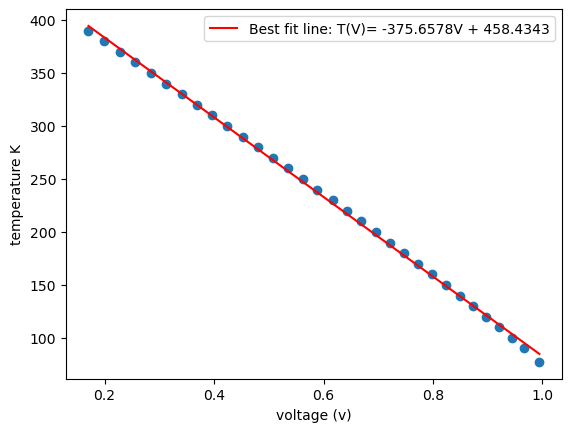

In [2]:
import numpy as np
import matplotlib.pyplot as plt

voltage_mv = [
    994.419,
    967.032,
    944.477,
    921.305,
    897.616,
    873.417,
    848.864,
    823.964,
    798.691,
    773.213,
    747.485,
    721.533,
    695.363,
    669.002,
    642.448,
    616.748,
    588.907, 561.655, 534.655, 507.311, 479.881, 
    452.258, 424.465, 396.645, 368.731, 340.625, 
    312.542, 284.206, 255.855, 227.428, 198.940, 
    170.463
]

voltage_v= [v*1e-3 for v in voltage_mv]
    
temp_k= [
    77.32,
    90,
    100,
    110,
    120,
    130,
    140,
    150,
    160,
    170,
    180,
    190,
    200,
    210,
    220,
    230, 240, 250, 260, 270, 280, 290, 300, 310, 
    320, 330, 340, 350, 360, 370, 380, 390
]


fit=np.polyfit(voltage_v,temp_k, 1)
bestfitline=np.polyval(fit, voltage_v)

slope=fit[0]
intercept=fit[1]


print(f"Best fit line equation: y = {slope:.5f}x + {intercept:.5f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')

plt.plot(voltage_v, bestfitline,color='red', label=f"Best fit line: T(V)= {slope:.4f}V + {intercept:.4f}")

plt.scatter(voltage_v, temp_k)
plt.ylabel('temperature K')
plt.xlabel('voltage (v)')
plt.legend()
plt.savefig('Temperature Calibration', dpi= 300)


### Conversion using calibration equation

In [3]:
V_Ra_mv= [985, 972, 965, 958, 954, 950, 946, 936, 926, 916, 906, 896, 886, 876, 866, 856, 846, 836, 826, 816, 806, 794, 786, 776, 766, 756, 746, 736, 726, 714, 706, 696, 686, 676, 666, 655, 646, 636, 626, 616, 606, 596, 586, 576, 566, 556, 546, 536, 526, 516, 506, 496, 486, 476, 466, 456, 446, 436, 426, 416, 406, 396, 386, 377, 365, 356, 346, 336, 326, 316, 306, 296, 286, 276, 266, 256, 246, 236, 226, 216, 206]

V_Ra=[v*1e-3 for v in V_Ra_mv]
T_Ra= [(x*(-375.657) + 458.4343) for x in V_Ra]

print(len(V_Ra))
print(len(T_Ra))



81
81


### calculation Ra_1

22
59
81
81
Best fit line equation: y = 0.0000000000x + 0.0000000000
Best fit line: V= 5.704244319369251e-16 + 7.133218913099618e-12


Text(0, 0.5, 'Voltage (V)')

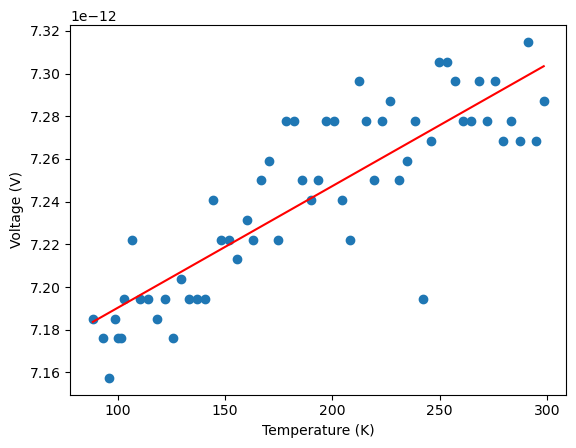

In [4]:
v1_Ra_avg = [
    0.2586666667,
    0.2583333333,
    0.2576666667,
    0.2586666667,
    0.2583333333,
    0.2583333333,
    0.259,
    0.26,
    0.259,
    0.259,
    0.2586666667,
    0.259,
    0.2583333333,
    0.2593333333,
    0.259,
    0.259,
    0.259,
    0.2606666667,
    0.26,
    0.26,
    0.2596666667,
    0.2603333333,
    0.26,
    0.261,
    0.2613333333,
    0.26,
    0.262,
    0.262,
    0.261,
    0.2606666667,
    0.261,
    0.262,
    0.262,
    0.2606666667,
    0.26,
    0.2626666667,
    0.262,
    0.261,
    0.262,
    0.2623333333,
    0.261,
    0.2613333333,
    0.262,
    0.259,
    0.2616666667,
    0.263,
    0.263,
    0.2626666667,
    0.262,
    0.262,
    0.2626666667,
    0.262,
    0.2626666667,
    0.2616666667,
    0.262,
    0.2616666667,
    0.2633333333,
    0.2616666667,
    0.2623333333
]


gain_1 = 1000
vj_vn_1_Ra = [(v * 10) / ((gain_1 * 600)**2) for v in v1_Ra_avg]


v2_Ra_avg = [
    0.572,
    0.576,
    0.576,
    0.5763333333,
    0.5743333333,
    0.5796666667,
    0.579,
    0.5813333333,
    0.5803333333,
    0.5793333333,
    0.579,
    0.5806666667,
    0.581,
    0.586,
    0.5803333333,
    0.5816666667,
    0.5833333333,
    0.5836666667,
    0.5833333333,
    0.586,
    0.5883333333,
    0.5866666667
]


gain_2=1500
vj_vn_2_Ra= [(v * 10) / ((gain_2 * 600)**2) for v in v2_Ra_avg]

vj_vn_Ra= vj_vn_1_Ra + vj_vn_2_Ra

print(len(v2_Ra_avg))
print(len(v1_Ra_avg))
print(len(vj_vn_Ra))
print(len(T_Ra))

# plt.scatter(T_Ra, vj_vn_Ra)
T_Ra_1=T_Ra[0:59]
T_Ra_2 = T_Ra[59:]

plt.scatter(T_Ra_1, vj_vn_1_Ra)

fit=np.polyfit(T_Ra_1, vj_vn_1_Ra, 1)
bestfitline=np.polyval(fit, T_Ra_1)

slope=fit[0]
intercept=fit[1]

print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')

plt.plot(T_Ra_1, bestfitline,color='red') 
print(f"Best fit line: V= {slope:} + {intercept:}")

plt.xlabel('Temperature (K)')
plt.ylabel('Voltage (V)')

### Calculation Ra_2

Best fit line equation: y = 0.0000000000x + 0.0000000000
Best fit line: V= 1.9147179120803422e-15 + 6.514460063359135e-12


Text(0, 0.5, 'Voltage (V)')

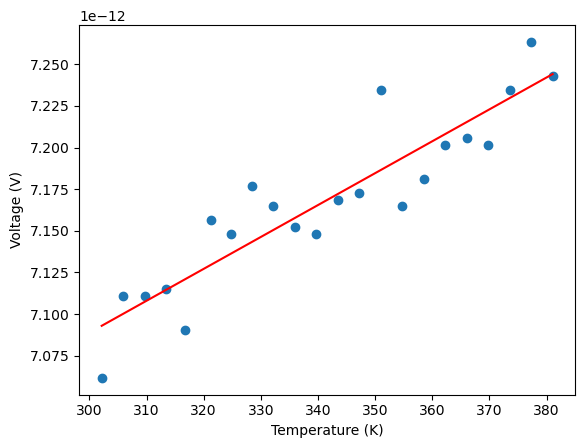

In [5]:
plt.scatter(T_Ra_2, vj_vn_2_Ra)

fit=np.polyfit(T_Ra_2, vj_vn_2_Ra, 1)
bestfitline=np.polyval(fit, T_Ra_2)

slope=fit[0]
intercept=fit[1]

print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')

plt.plot(T_Ra_2, bestfitline,color='red') 
print(f"Best fit line: V= {slope:} + {intercept:}")

plt.xlabel('Temperature (K)')
plt.ylabel('Voltage (V)')

### Calculation Rb1

233.40636557500002
Slope = 4.6189823299954966e-14
Uncertainty in slope = 2.0130004020744193e-16
Best fit line equation: y = 0.0000000000x + 0.0000000000
Best fit line: V= 4.6189823299954966e-14 + 7.60580677256161e-12


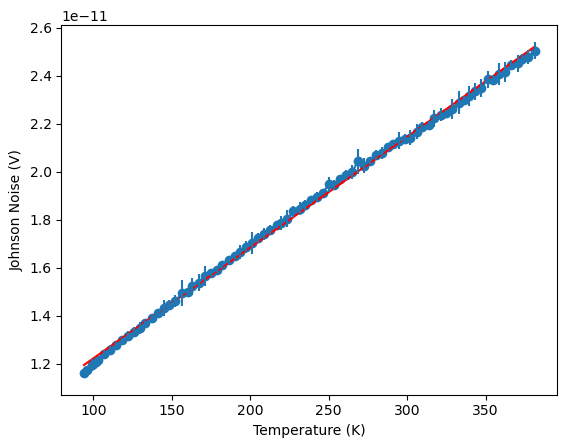

In [21]:
V_Rb = [
    0.97, 0.964, 0.957, 0.954, 0.95, 0.946, 0.936, 0.925, 0.915, 0.905,
    0.896, 0.885, 0.875, 0.866, 0.855, 0.845, 0.835, 0.825, 0.815, 0.804,
    0.793, 0.786, 0.775, 0.765, 0.754, 0.745, 0.735, 0.724, 0.714, 0.705,
    0.695, 0.685, 0.674, 0.665, 0.655, 0.642, 0.635, 0.625, 0.615, 0.604,
    0.595, 0.585, 0.575, 0.565, 0.554, 0.545, 0.535, 0.525, 0.515, 0.505,
    0.495, 0.485, 0.475, 0.465, 0.455, 0.445, 0.435, 0.425, 0.416, 0.405,
    0.396, 0.385, 0.376, 0.365, 0.355, 0.345, 0.334, 0.325, 0.316, 0.306,
    0.296, 0.285, 0.276, 0.266, 0.256, 0.245, 0.234, 0.226, 0.216, 0.205
]
T_Rb= [(x*(-375.657) + 458.4343) for x in V_Rb]

T_Rb_avg = np.mean(T_Rb)
print(T_Rb_avg)
v_Rb_avg = [
    0.418,
    0.4226666667,
    0.4303333333,
    0.4316666667,
    0.4346666667,
    0.4373333333,
    0.446,
    0.4523333333,
    0.4603333333,
    0.467,
    0.474,
    0.4793333333,
    0.4863333333,
    0.493,
    0.5,
    0.5086666667,
    0.5156666667,
    0.52,
    0.526,
    0.538,
    0.5403333333,
    0.5483333333,
    0.5536666667,
    0.5636666667,
    0.568,
    0.573,
    0.58,
    0.5873333333,
    0.5943333333,
    0.6,
    0.6066666667,
    0.6133333333,
    0.6203333333,
    0.6266666667,
    0.633,
    0.6406666667,
    0.643,
    0.6496666667,
    0.6606666667,
    0.665,
    0.6696666667,
    0.6776666667,
    0.6823333333,
    0.689,
    0.7013333333,
    0.7006666667,
    0.709,
    0.7146666667,
    0.72,
    0.736,
    0.7293333333,
    0.736,
    0.7453333333,
    0.7476666667,
    0.757,
    0.762,
    0.767,
    0.7696666667,
    0.7713333333,
    0.7803333333,
    0.7873333333,
    0.7906666667,
    0.8003333333,
    0.806,
    0.809,
    0.8143333333,
    0.8236666667,
    0.8276666667,
    0.8336666667,
    0.841,
    0.8456666667,
    0.859,
    0.8583333333,
    0.867,
    0.8693333333,
    0.88,
    0.8826666667,
    0.889,
    0.8923333333,
    0.902
]

gain=1000
vj_vn_Rb= [(v * 10) / ((gain * 600)**2) for v in v_Rb_avg]

plt.scatter(T_Rb,vj_vn_Rb)
plt.xlabel('Temperature (K)')
plt.ylabel('Johnson Noise (V)')

# fit=np.polyfit(T_Rb, vj_vn_Rb, 1)
# bestfitline=np.polyval(fit, T_Rb)

(m, b), cov = np.polyfit(T_Rb, vj_vn_Rb, 1, cov=True)
bestfitline=np.polyval((m,b), T_Rb)

slope = m
intercept= b
slope_uncertainty = np.sqrt(cov[0, 0])

print("Slope =", slope)
print("Uncertainty in slope =", slope_uncertainty)

print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')
std_vj_vn_mv= vals = [
    2,
    1.527525232,
    2.516611478,
    1.527525232,
    2.081665999,
    0.5773502692,
    2,
    2.081665999,
    1.154700538,
    1,
    2,
    2.081665999,
    2.516611478,
    1,
    2,
    1.527525232,
    3.511884584,
    2,
    2.645751311,
    5.291502622,
    1.527525232,
    3.511884584,
    3.511884584,
    4.041451884,
    1,
    1,
    1,
    1.527525232,
    1.527525232,
    3,
    2.516611478,
    4.509249753,
    2.081665999,
    2.516611478,
    2,
    1.527525232,
    3,
    3.511884584,
    2.309401077,
    2.645751311,
    2.081665999,
    1.527525232,
    2.081665999,
    1,
    3.214550254,
    2.081665999,
    1,
    2.081665999,
    3,
    5.291502622,
    3.055050463,
    1,
    2.081665999,
    2.516611478,
    1,
    1,
    3.605551275,
    2.081665999,
    3.214550254,
    3.055050463,
    2.081665999,
    1.527525232,
    3.511884584,
    2.645751311,
    1,
    4.041451884,
    4.725815626,
    1.527525232,
    4.163331999,
    3.605551275,
    3.785938897,
    3.464101615,
    2.081665999,
    4.582575695,
    4.163331999,
    2,
    3.511884584,
    2,
    3.055050463,
    3.605551275
]
std_vj_vn =[x*1e-13 for x in std_vj_vn_mv]

plt.plot(T_Rb, bestfitline,color='red') 
plt.errorbar(T_Rb, vj_vn_Rb , yerr=std_vj_vn, label='error bars')

print(f"Best fit line: V= {slope:} + {intercept:}")
plt.savefig('Johnson Noise vs Temperature', dpi = 300)


### Calculation Rc

Slope = 9.106218034317194e-14
Uncertainty in slope = 4.007544421093474e-16
Best fit line: V= 9.106218034317194e-14 + 9.35687669677707e-12


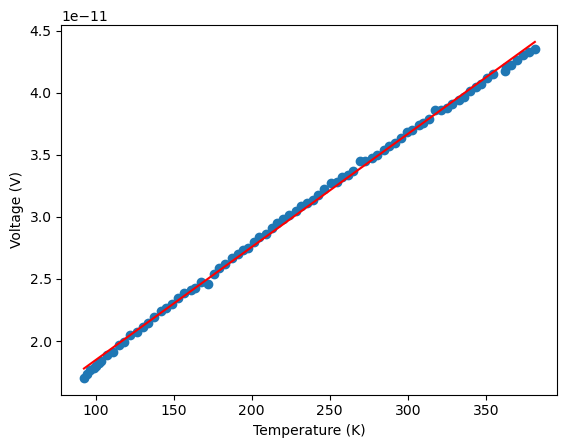

In [7]:
V_Rc = [
    0.974,
    0.969,
    0.963,
    0.957,
    0.953,
    0.949,
    0.945,
    0.934,
    0.924,
    0.914,
    0.905,
    0.895,
    0.884,
    0.874,
    0.865,
    0.854,
    0.843,
    0.834,
    0.824,
    0.813,
    0.803,
    0.791,
    0.785,
    0.774,
    0.763,
    0.753,
    0.743,
    0.733,
    0.722,
    0.712,
    0.703,
    0.694,
    0.684,
    0.675,
    0.663,
    0.654,
    0.644,
    0.634,
    0.624,
    0.613,
    0.603,
    0.594,
    0.584,
    0.574,
    0.564,
    0.553,
    0.543,
    0.534,
    0.524,
    0.515,
    0.504,
    0.494,
    0.483,
    0.474,
    0.463,
    0.454,
    0.444,
    0.434,
    0.423,
    0.414,
    0.402,
    0.395,
    0.385,
    0.375,
    0.365,
    0.355,
    0.346,
    0.334,
    0.325,
    0.316,
    0.306,
    0.296,
    0.286,
    0.276,
    0.256,
    0.255,
    0.245,
    0.235,
    0.225,
    0.215,
    0.205
]

T_Rc= [(x*(-375.657) + 458.4343) for x in V_Rc]

v1_Rc_avg=  [
    0.613,
    0.6253333333,
    0.6373333333,
    0.6423333333,
    0.6486666667,
    0.655,
    0.6626666667,
    0.6783333333,
    0.6876666667,
    0.709,
    0.7173333333,
    0.7363333333,
    0.7473333333,
    0.762,
    0.7723333333,
    0.7893333333,
    0.8066666667,
    0.8146666667,
    0.8266666667,
    0.8443333333,
    0.8586666667,
    0.869,
    0.8736666667,
    0.8913333333,
    0.8846666667,
    0.9156666667,
    0.931,
    0.9443333333,
    0.9606666667,
    0.9713333333,
    0.9833333333,
    0.991,
    1.008,
    1.020666667,
    1.029333333,
    1.048666667,
    1.063,
    1.074,
    1.085666667,
    1.098,
    1.110333333,
    1.119,
    1.128333333,
    1.142,
    1.159666667,
    1.177333333,
    1.181666667,
    1.197,
    1.202333333,
    1.212666667,
    1.241,
    1.241666667,
    1.250666667,
    1.259333333,
    1.272666667,
    1.285,
    1.294,
    1.308333333,
    1.324666667
]

gain_1=1000
vj_vn_Rc_1= [(v * 10) / ((gain_1 * 600)**2) for v in v1_Rc_avg]


v2_Rc_avg=[
    0.853,
    0.8613333333,
    0.8656666667,
    0.8733333333,
    0.8903333333,
    0.8896666667,
    0.893,
    0.9013333333,
    0.9076666667,
    0.9143333333,
    0.924,
    0.9313333333,
    0.9386666667,
    0.949,
    0.957,
    0.9616666667,
    0.9686666667,
    0.9736666667,
    0.982,
    0.9913333333,
    0.997,
    1.003
]

gain_2=800
vj_vn_Rc_2= [(v * 10) / ((gain_2 * 600)**2) for v in v2_Rc_avg]

vj_vn_Rc= vj_vn_Rc_1 + vj_vn_Rc_2

plt.scatter(T_Rc,vj_vn_Rc)
plt.xlabel('Temperature (K)')
plt.ylabel('Voltage (V)')

# fit=np.polyfit(T_Rc, vj_vn_Rc, 1)
# bestfitline=np.polyval(fit, T_Rc)

(m, b), cov = np.polyfit(T_Rc, vj_vn_Rc, 1, cov=True)
bestfitline=np.polyval((m,b), T_Rc)

slope = m
intercept= b
slope_uncertainty = np.sqrt(cov[0, 0])

print("Slope =", slope)
print("Uncertainty in slope =", slope_uncertainty)
# slope=fit[0]
# intercept=fit[1]

# print(f"Best fit line equation: y = {slope:.10f}x + {intercept:.10f}")

# plt.errorbar(current, avg_tesla ,yerr=r_err, linestyle='none', capsize=5, ecolor='blue', label='Errorbar')

plt.plot(T_Rc, bestfitline,color='red') 
print(f"Best fit line: V= {slope:} + {intercept:}")
